In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_directory = '/content/drive/MyDrive/Project/ArSarcasm-v2/03_train/01'
num_epochs = 20
early_stopping_patience = 6

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, BertPreTrainedModel
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score)

from torch.utils.tensorboard import SummaryWriter
import pandas as pd
import numpy as np

import seaborn as sns
from sklearn.metrics import auc  # For calculating AUPRC
import matplotlib.pyplot as plt

from collections import Counter

from transformers import AutoTokenizer, AutoModel

import torch.nn.functional as F

from sklearn.metrics import precision_recall_curve

from typing import Dict, List, Tuple

In [ ]:
import time
def shutdown_sys():
  print('Will Shutdown')
  time.sleep(30)
  from google.colab import runtime
  runtime.unassign()

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
class MultiTaskBert(BertPreTrainedModel):
    def __init__(self, config, num_labels_per_task, model_name, dropout_probability):
        super().__init__(config)
        self.bert = AutoModel.from_pretrained(model_name, config=config)
        self.dropout = nn.Dropout(p=dropout_probability)

        self.classification_heads = nn.ModuleDict({
            f'task_{i}': nn.Linear(config.hidden_size, num_labels)
            for i, num_labels in enumerate(num_labels_per_task)
        })

    def forward(self, input_ids, attention_mask, task=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        pooled_output = torch.mean(hidden_states, dim=1)
        pooled_output = self.dropout(pooled_output)
        return self.classification_heads[task](pooled_output)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        logpt = F.log_softmax(inputs, dim=1)
        pt = torch.exp(logpt)

        logpt = logpt.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = pt.gather(1, targets.unsqueeze(1)).squeeze(1)

        loss = - (1 - pt) ** self.gamma * logpt

        if self.alpha is not None:
            # Move alpha to the same device as targets
            alpha = self.alpha.to(targets.device)
            alpha_factor = alpha.gather(0, targets)
            loss = alpha_factor * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

In [ ]:
from torch.optim.lr_scheduler import LambdaLR
def create_linear_scheduler(optimizer, num_epochs, last_epoch=-1):
    """
    Creates a linear learning rate scheduler that updates once per epoch
    """
    def lr_lambda(epoch):
        # Linear decay from 1 to 0.1 over all epochs
        return 1.0 - 0.9 * (epoch / num_epochs)

    return LambdaLR(optimizer, lr_lambda, last_epoch=last_epoch)


In [ ]:
def do_train(train_config, df_train, df_val, label_encoders, loss_functions, num_labels_per_task, model=None):
    model_name = train_config['model_name']
    task_id_to_name = train_config['task_id_to_name']
    num_epochs = train_config['num_epochs']
    batch_size = train_config['batch_size']
    save_directory = train_config['save_directory']
    learning_rate = train_config['learning_rate']
    dropout_probability = train_config['dropout_probability']
    patience = train_config['early_stopping_patience']

    tokenizer = BertTokenizer.from_pretrained(model_name)
    tokenizer.save_pretrained(f'{save_directory}/tokenizer')
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use the passed model if provided, otherwise instantiate a new one.
    if model is None:
        # Create a new model
        model_config = BertModel.from_pretrained(model_name).config
        multi_task_model = MultiTaskBert(model_config, num_labels_per_task, model_name, dropout_probability).to(device)
        print("Training new model from scratch.")
        print("Model config:", model_config)
    else:
        # Fine-tune the passed pre-trained model.
        multi_task_model = model.to(device)
        print("Fine-tuning a pre-trained model.")

    MAX_NUMBER_OF_TOKENS = multi_task_model.config.max_position_embeddings

    optimizer = torch.optim.AdamW(multi_task_model.parameters(),
                                lr=learning_rate,
                                weight_decay=0.1)

    print("Train config:\n", train_config)
    print(multi_task_model)

    # Create data loaders for each task.
    train_data_loaders = [create_data_loader(df, tokenizer, MAX_NUMBER_OF_TOKENS, batch_size=batch_size) for df in df_train]
     = [create_data_loader(df, tokenizer, MAX_NUMBER_OF_TOKENS, batch_size=batch_size) for df in df_val]

    num_batches_per_task = [len(loader) for loader in train_data_loaders]
    num_all_tasks_batches_per_epoch = sum(num_batches_per_task)
    total_batches_all_epochs = num_all_tasks_batches_per_epoch * num_epochs

    print(f'Number of epochs= {num_epochs}')
    print(f'Number of tasks = {len(train_data_loaders)}')
    print(f'Number of train records per task={[len(df) for df in df_train]}')
    print(f'batch_size={batch_size}')
    print(f'Number of batches in each task per epoch={num_batches_per_task}')
    print(f'Number of batches across all tasks per epoch= {num_all_tasks_batches_per_epoch}')
    print(f'Number of batches over all epochs= {total_batches_all_epochs}')


    scheduler = create_linear_scheduler(optimizer, num_epochs)

    train_all_epochs(multi_task_model, task_id_to_name, train_data_loaders, val_data_loaders,
                     num_epochs, optimizer, scheduler, save_directory, loss_functions, patience, label_encoders)

In [ ]:
def create_data_loader(df, tokenizer, max_length, batch_size):
    ds = CustomDataset(
        texts=df.text.to_numpy(),
        labels=df.label.to_numpy(),
        sources=df.source.to_numpy() if 'source' in df.columns else np.array(['original'] * len(df)),  # Add source info
        tokenizer=tokenizer,
        max_length=max_length
    )
    return DataLoader(ds, batch_size=batch_size, num_workers=2)

In [ ]:
def compute_metrics(true_labels, preds):
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(true_labels, preds)

    report = classification_report(true_labels, preds, zero_division=0)
    print(report)

    return precision, recall, f1, acc

In [ ]:
def round_robin_loader(data_loaders):
    iterators = [iter(loader) for loader in data_loaders]
    while iterators:
        for i, it in enumerate(iterators):
            try:
                yield next(it), i
            except StopIteration:
                iterators.pop(i)

In [ ]:
def train_epoch(model, train_data_loaders, loss_functions, optimizer, scheduler,
                task_id_to_name, label_encoders):
    model.train()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize task tracking
    task_loss_history = [[] for _ in range(len(train_data_loaders))]
    metrics = {task_id: {"preds": [], "labels": [], "losses": []}
               for task_id in range(len(train_data_loaders))}
    total_steps = sum(len(loader) for loader in train_data_loaders)

    # Training loop using round_robin_loader
    for step, (batch, task_id) in enumerate(round_robin_loader(train_data_loaders)):
        task_name = task_id_to_name[task_id]

        # Forward pass
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'text'}
        logits = model(**inputs, task=f'task_{task_id}')
        loss = loss_functions[task_id](logits, inputs['labels'])

        # Backward pass
        loss.backward()

        # Compute gradient norm BEFORE zeroing gradients
        current_grad_norm = sum(
            p.grad.norm().item()
            for p in model.parameters()
            if p.grad is not None
        )

        recent_loss = np.mean(task_loss_history[task_id][-10:] or [0])
        clip_value = 1.0 + (2.0 if recent_loss > 1.0 else recent_loss)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        optimizer.step()
        optimizer.zero_grad()

        # Update metrics
        metrics[task_id]["preds"].append(logits.argmax(1).cpu().numpy())
        metrics[task_id]["labels"].append(inputs['labels'].cpu().numpy())
        metrics[task_id]["losses"].append(loss.item())
        task_loss_history[task_id].append(loss.item())

        # Logging (every 50 steps)
        if (step + 1) % 50 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Step {step+1}/{total_steps} | Task: {task_name}")
            print(f"  Loss: {loss.item():.4f} | LR: {lr:.1e} | GradNorm: {current_grad_norm:.5f}")
            print("-" * 60)

    scheduler.step()

    # Calculate metrics per task
    macro_f1, weighted_f1, avg_loss_total = 0.0, 0.0, 0.0
    task_weights, total_samples = [], 0

    # Filter out tasks with no losses
    filtered_metrics = {}
    for task_id in metrics:
        if not metrics[task_id]["losses"]:
            continue  # Skip tasks with no data

        labels = np.concatenate(metrics[task_id]["labels"])
        preds = np.concatenate(metrics[task_id]["preds"])
        class_names = label_encoders[task_id].classes_

        # Compute metrics
        precision, recall, f1, acc = compute_metrics(labels, preds)
        avg_loss = np.mean(metrics[task_id]["losses"])

        # Update metrics dict
        metrics[task_id].update({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": acc,
            "avg_loss": avg_loss
        })

        # Add to filtered_metrics
        filtered_metrics[task_id] = metrics[task_id]

        # Aggregate totals
        task_weight = 1 / (avg_loss + 1e-6)
        macro_f1 += f1
        weighted_f1 += f1 * len(labels)
        avg_loss_total += avg_loss * task_weight
        total_samples += len(labels)
        task_weights.append(task_weight)

    # Normalize metrics
    if task_weights:
        macro_f1 /= len(task_weights)
        weighted_f1 /= total_samples
        avg_loss_total /= sum(task_weights)

    return filtered_metrics, macro_f1, weighted_f1, avg_loss_total

In [ ]:
def evaluate_model(model, val_data_loaders, loss_functions, label_encoders):  # Added label_encoders parameter
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    task_results = {
        task_id: {"texts": [], "preds": [], "labels": [], "losses": [], "probs": []}
        for task_id in range(len(val_data_loaders))
    }

    with torch.no_grad():
        for task_id, val_loader in enumerate(val_data_loaders):
            if len(val_loader) == 0:  # Skip empty loaders
                continue

            # Process all batches for this task
            for batch in val_loader:
                texts = batch["text"]
                task_results[task_id]["texts"].extend(texts)

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                logits = model(input_ids, attention_mask, task=f'task_{task_id}')

                if "source" in batch:
                    sources = batch["source"].to(device)
                else:
                    sources = torch.ones_like(labels).float().to(device)
                loss = loss_functions[task_id](logits, labels)

                probs = torch.softmax(logits, dim=1).cpu().numpy()
                preds = logits.argmax(1)

                # Store batch results
                task_results[task_id]["preds"].extend(preds.cpu().numpy())
                task_results[task_id]["labels"].extend(labels.cpu().numpy())
                task_results[task_id]["losses"].append(loss.item())
                task_results[task_id]["probs"].append(probs)

            # Print confidence stats AFTER processing all batches for this task
            if task_results[task_id]["probs"]:
                all_probs = np.concatenate(task_results[task_id]["probs"], axis=0)
                classes = label_encoders[task_id].classes_
                print(f"\nTask {task_id} Confidence Stats:")
                for class_idx, class_name in enumerate(classes):
                    class_probs = all_probs[:, class_idx]
                    print(f"Val Class {class_idx} ({class_name}): "
                          f"Mean={class_probs.mean():.2f}, "
                          f"Max={class_probs.max():.2f}")

    # Compute metrics per task
    metrics = {}
    total_f1 = 0.0
    total_loss = 0.0
    task_sample_counts = []

    for task_id in task_results:
        if len(task_results[task_id]["losses"]) == 0:
            continue

        labels = np.array(task_results[task_id]["labels"])
        preds = np.array(task_results[task_id]["preds"])
        losses = task_results[task_id]["losses"]
        probs = np.concatenate(task_results[task_id]["probs"], axis=0)

        print(f'\n\nEvaluation metrics for Task {task_id}:')
        precision, recall, f1, acc = compute_metrics(labels, preds)
        avg_loss = np.mean(losses)

        metrics[task_id] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": acc,
            "avg_loss": avg_loss,
            "n_samples": len(labels),
            "labels": labels,
            "preds": preds,
            "probs": probs
        }
        total_f1 += f1
        total_loss += avg_loss
        task_sample_counts.append(len(labels))

    # Calculate aggregate metrics
    macro_f1 = total_f1 / len(metrics) if metrics else 0
    avg_loss = total_loss / len(metrics) if metrics else 0
    weighted_f1 = sum(metrics[t]["f1"] * metrics[t]["n_samples"] for t in metrics) / sum(task_sample_counts) if metrics else 0

    print(f'\nValidation Completed - Tasks Processed: {len(metrics)}')
    return metrics, macro_f1, weighted_f1, avg_loss, task_results

In [ ]:
def train_all_epochs(multi_task_model, task_id_to_name, train_data_loaders, val_data_loaders, num_epochs, optimizer, scheduler,
                     save_directory, loss_functions, patience, label_encoders):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # best_macro_f1 = 0 #float('inf')
    best_macro_f1 = 0
    epochs_no_improve = 0  # Counter for epochs without improvement
    early_stop = False  # Flag to indicate early stopping

    number_of_training_loaders = len(train_data_loaders)
    writer = SummaryWriter(log_dir='runs/tensorboard_writer')

    for epoch in range(num_epochs):
        if early_stop:
            print("Early stopping triggered.")
            break

        print(f'********** epoch {epoch + 1} start **********')
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")

        # Train
        train_metrics, train_macro_f1, train_weighted_f1, train_avg_loss = train_epoch(multi_task_model, train_data_loaders, loss_functions,
                                                                                       optimizer, scheduler, task_id_to_name, label_encoders)
        # Log metrics
        writer.add_scalar('Train/Macro F1', train_macro_f1, epoch)
        writer.add_scalar('Train/Weighted F1', train_weighted_f1, epoch)
        writer.add_scalar('Train/Loss', train_avg_loss, epoch)

        # Print per-task metrics
        print("\nTraining Metrics per Task:")
        for task_id, metrics in train_metrics.items():
            task_name = task_id_to_name.get(task_id, f"Task {task_id}")
            print(f"{task_name}: F1={metrics['f1']:.4f}, Loss={metrics['avg_loss']:.4f}")
        print(f'train_macro_f1={train_macro_f1}, train_weighted_f1={train_weighted_f1}, train_avg_loss={train_avg_loss}')

        # Evaluate
        val_metrics, val_macro_f1, val_weighted_f1, val_avg_loss, _ = evaluate_model(multi_task_model, val_data_loaders, loss_functions,
                                                                                     label_encoders)
        # Log validation metrics
        writer.add_scalar('Val/Macro F1', val_macro_f1, epoch)
        writer.add_scalar('Val/Weighted F1', val_weighted_f1, epoch)
        writer.add_scalar('Val/Loss', val_avg_loss, epoch)

        # Print per-task metrics
        print("\nValidation Metrics per Task:")
        for task_id, metrics in val_metrics.items():
            task_name = task_id_to_name.get(task_id, f"Task {task_id}")
            print(f"{task_name}: "
                  f"F1={metrics['f1']:.4f}, Acc={metrics['accuracy']:.4f}, "
                  f"Loss={metrics['avg_loss']:.4f}, n_samples={metrics['n_samples']}")
        print(f'val_macro_f1={val_macro_f1}, val_weighted_f1={val_weighted_f1}, val_avg_loss={val_avg_loss}')

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            torch.save(multi_task_model, f'{save_directory}/best_multi_task_model.bin')
            print(f"Saved new best model with validation macro F1: {val_macro_f1:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in validation macro F1 for {epochs_no_improve} epochs. "
                  f"Best macro F1: {best_macro_f1:.4f}")

        # Early stopping check
        if epochs_no_improve >= patience:
            early_stop = True

    writer.close()

In [ ]:
def calculate_class_metrics_and_confusion_matrix(all_labels, all_preds, label_encoder):
    all_labels_transformed = label_encoder.inverse_transform(all_labels)
    all_preds_transformed = label_encoder.inverse_transform(all_preds)

    class_report = classification_report(all_labels_transformed, all_preds_transformed, output_dict=True)
    conf_matrix = confusion_matrix(all_labels_transformed, all_preds_transformed)
    return class_report, conf_matrix

In [ ]:
def plot_confusion_matrix(conf_matrix, task_name, label_encoder):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix for {task_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

In [ ]:
def calculate_test_model_all_tasks_and_show_results(model_config, model, tokenizer, df_test,
                                                  label_encoders, loss_functions, best_thresholds=None):
    MAX_NUMBER_OF_TOKENS = model.config.max_position_embeddings
    task_id_to_name = model_config['task_id_to_name']
    batch_size = model_config['batch_size']

    # Create data loaders
    test_data_loaders = [create_data_loader(df, tokenizer, MAX_NUMBER_OF_TOKENS, batch_size)
                         for df in df_test]

    # Evaluate model with label_encoders passed
    test_metrics, test_macro_f1, test_weighted_f1, test_avg_loss, test_results = evaluate_model(
        model, test_data_loaders, loss_functions, label_encoders  # Added label_encoders
    )

    # Rest of the function remains unchanged
    print("\n=== Overall Test Metrics ===")
    print(f"Macro F1: {test_macro_f1:.4f}")
    print(f"Weighted F1: {test_weighted_f1:.4f}")
    print(f"Average Loss: {test_avg_loss:.4f}\n")

    results_dfs = {}

    for task_id, metrics in test_metrics.items():
        task_name = task_id_to_name.get(task_id, f"Task {task_id}")
        print(f"\n{task_name}:")
        print(f"  F1: {metrics['f1']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Loss: {metrics['avg_loss']:.4f}")
        print(f"  Samples: {metrics['n_samples']}")

        probs = np.concatenate(test_results[task_id]["probs"], axis=0)
        texts = test_results[task_id]["texts"]
        true_labels = np.array(test_results[task_id]["labels"])
        classes = label_encoders[task_id].classes_

        # Threshold handling
        if best_thresholds and task_id in best_thresholds:
            task_thresholds = best_thresholds[task_id]
            thresholds = np.array([task_thresholds[cls] for cls in classes])
            above_or_equals_threshold = probs >= thresholds

            final_preds = np.zeros(probs.shape[0], dtype=int)
            for i in range(probs.shape[0]):
                valid_indices = np.where(above_or_equals_threshold[i])[0]
                if valid_indices.size > 0:
                    final_preds[i] = valid_indices[np.argmax(probs[i, valid_indices])]
                else:
                    final_preds[i] = np.argmax(probs[i])
        else:
            final_preds = np.argmax(probs, axis=1)

        # Create and store results
        task_df = create_task_dataframe(
            texts, true_labels, final_preds, label_encoders[task_id], probs
        )
        results_dfs[task_name] = task_df

        print_classification_report(task_name, true_labels, final_preds, label_encoders[task_id])

    return results_dfs

In [ ]:
def create_task_dataframe(texts, true_labels, preds, label_encoder, probs):
    df = pd.DataFrame({
        "text": texts,
        "true_label": label_encoder.inverse_transform(true_labels),
        "predicted_label": label_encoder.inverse_transform(preds)
    })
    for idx, class_name in enumerate(label_encoder.classes_):
        df[f'prob_{class_name}'] = probs[:, idx]
    return df

In [ ]:
def print_classification_report(task_name, true_labels, preds, label_encoder):
    print(f"\nClassification Report for {task_name}:")
    class_report, conf_matrix = calculate_class_metrics_and_confusion_matrix(
        true_labels, preds, label_encoder
    )
    print(pd.DataFrame(class_report).transpose())
    plot_confusion_matrix(conf_matrix, task_name, label_encoder)

In [ ]:
import os

def run_test_with_thresholds(model, tokenizer, test_df, label_encoders,
                            loss_functions, train_config, suffix, thresholds=None):
    results = calculate_test_model_all_tasks_and_show_results(
        train_config, model, tokenizer, test_df,
        label_encoders, loss_functions, thresholds
    )

    # Create save directory if missing
    save_dir = train_config['save_directory']
    os.makedirs(save_dir, exist_ok=True)

    return results

In [ ]:
def get_task_thresholds(val_results, label_encoders):
    best_thresholds = {}
    for task_id in range(len(val_results)):
        classes = label_encoders[task_id].classes_
        val_probs = np.concatenate(val_results[task_id]["probs"])
        val_true = np.array(val_results[task_id]["labels"])

        task_thresholds = {}
        for class_idx, class_name in enumerate(classes):
            y_true = (val_true == class_idx).astype(int)
            if np.sum(y_true) == 0:
                task_thresholds[class_name] = 1.0
                continue

            y_scores = val_probs[:, class_idx]
            precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
            thresholds = np.append(thresholds, 1.0)
            f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
            best_idx = np.nanargmax(f1_scores)
            task_thresholds[class_name] = thresholds[best_idx]

        best_thresholds[task_id] = task_thresholds
    return best_thresholds

In [ ]:
def load_trained_model(train_config, model_file):
    dir = train_config['save_directory']
    model = torch.load(f'{dir}/{model_file}', weights_only=False)
    tokenizer = AutoTokenizer.from_pretrained(train_config['model_name'])
    return model, tokenizer

In [ ]:
def plot_pr_curves_per_task(results_dict, label_encoders, task_names, best_thresholds=None):
    plt.figure(figsize=(10, 6 * len(results_dict)))

    for task_id, task_name in enumerate(results_dict.keys()):
        plt.subplot(len(results_dict), 1, task_id + 1)

        # Get the DataFrame for this task
        task_df = results_dict[task_name]

        # Extract true labels and probabilities
        y_true = task_df["true_label"].values
        classes = label_encoders[task_id].classes_
        y_probs = task_df[[f'prob_{cls}' for cls in classes]].values

        # Plot PR curve for each class
        for class_idx, class_name in enumerate(classes):
            binary_true = (y_true == class_name).astype(int)
            precision, recall, _ = precision_recall_curve(binary_true, y_probs[:, class_idx])
            auprc = auc(recall, precision)
            plt.plot(recall, precision, label=f'{class_name} (AUPRC={auprc:.2f})')

        plt.title(f'Task {task_id}: {task_name}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
%%capture
!pip install tensorboard

In [ ]:
def print_df_info(name, df):
  print('*'*5)
  acopy = df.copy()
  print(f'len({name}) = {len(df)}')
  print('')
  print(acopy.groupby(['sarcasm']).size().reset_index(name='count'))
  print('')
  print(acopy.groupby(['sentiment']).size().reset_index(name='count'))
  print(acopy.groupby(['dialect']).size().reset_index(name='count'))
  print('')
  print(acopy.groupby('combined_label').size().reset_index(name='count').sort_values(by='count'))
  print('')
  print('*'*5)

In [ ]:
train_csv = '/content/drive/MyDrive/Project/ArSarcasm-v2/01_data_preparation/train.csv'
val_csv = '/content/drive/MyDrive/Project/ArSarcasm-v2/01_data_preparation/val.csv'
test_csv = '/content/drive/MyDrive/Project/ArSarcasm-v2/01_data_preparation/test.csv'

original_train_df = pd.read_csv(train_csv)
original_val_df = pd.read_csv(val_csv)
original_test_df = pd.read_csv(test_csv)

all_train_df = original_train_df.copy().sample(frac=1, random_state=42).reset_index(drop=True)
all_val_df = original_val_df.copy().sample(frac=1, random_state=42).reset_index(drop=True)
all_test_df = original_test_df.copy().sample(frac=1, random_state=42).reset_index(drop=True)


print_df_info('all_train_df', all_train_df)
print_df_info('all_val_df', all_val_df)
print_df_info('all_test_df', all_test_df)

*****
len(all_train_df) = 10153

   sarcasm  count
0    False   8623
1     True   1530

  sentiment  count
0       NEG   3324
1       NEU   5106
2       POS   1723
  dialect  count
0   egypt   2423
1    gulf    390
2  levant    582
3  magreb     41
4     msa   6717

      combined_label  count
23   True,NEU,magreb      1
13  False,POS,magreb      6
21     True,NEU,gulf      7
26     True,POS,gulf      7
27   True,POS,levant      7
22   True,NEU,levant      8
8   False,NEU,magreb     10
3   False,NEG,magreb     11
18   True,NEG,magreb     13
28      True,POS,msa     15
25    True,POS,egypt     24
24      True,NEU,msa     30
20    True,NEU,egypt     44
1     False,NEG,gulf     53
11    False,POS,gulf     62
16     True,NEG,gulf     96
17   True,NEG,levant    112
12  False,POS,levant    131
2   False,NEG,levant    152
6     False,NEU,gulf    165
7   False,NEU,levant    172
19      True,NEG,msa    426
10   False,POS,egypt    464
0    False,NEG,egypt    486
5    False,NEU,egypt    665
15   

In [ ]:
sarcasm_train = all_train_df.copy()[['text', 'sarcasm']].rename(columns={'sarcasm': 'label'})
sarcasm_train['label'] = sarcasm_train['label'].astype(str)  # Convert to string

sentiment_train = all_train_df.copy()[['text', 'sentiment']].rename(columns={'sentiment': 'label'})
sentiment_train['label'] = sentiment_train['label'].astype(str)  # Convert to string

dialect_train = all_train_df.copy()[['text', 'dialect']].rename(columns={'dialect': 'label'})
dialect_train['label'] = dialect_train['label'].astype(str)  # Convert to string

sarcasm_val = all_val_df.copy()[['text', 'sarcasm']].rename(columns={'sarcasm': 'label'})
sarcasm_val['label'] = sarcasm_val['label'].astype(str)

sentiment_val = all_val_df.copy()[['text', 'sentiment']].rename(columns={'sentiment': 'label'})
sentiment_val['label'] = sentiment_val['label'].astype(str)

dialect_val = all_val_df.copy()[['text', 'dialect']].rename(columns={'dialect': 'label'})
dialect_val['label'] = dialect_val['label'].astype(str)

sarcasm_test = all_test_df.copy()[['text', 'sarcasm']].rename(columns={'sarcasm': 'label'})
sarcasm_test['label'] = sarcasm_test['label'].astype(str)

sentiment_test = all_test_df.copy()[['text', 'sentiment']].rename(columns={'sentiment': 'label'})
sentiment_test['label'] = sentiment_test['label'].astype(str)

dialect_test = all_test_df.copy()[['text', 'dialect']].rename(columns={'dialect': 'label'})
dialect_test['label'] = dialect_test['label'].astype(str)

train_df = [sarcasm_train, sentiment_train, dialect_train]
val_df = [sarcasm_val, sentiment_val, dialect_val]
test_df = [sarcasm_test, sentiment_test, dialect_test]

In [ ]:
train_config = {
    "model_name": 'aubmindlab/bert-base-arabertv02',
    "task_id_to_name": { 0: "Sarcasm", 1: "Sentiment", 2: "Dialect" },
    "num_epochs": num_epochs,
    "batch_size": 32,
    "save_directory": save_directory,
    "learning_rate": 5e-5,
    "dropout_probability": 0.3,
    "early_stopping_patience": early_stopping_patience,
}

In [ ]:
# After label encoding:
label_encoders = [LabelEncoder().fit(df.label) for df in train_df]

for i, df in enumerate(train_df):
    df['label'] = label_encoders[i].transform(df['label'])
for i, df in enumerate(val_df):
    df['label'] = label_encoders[i].transform(df['label'])
for i, df in enumerate(test_df):
    df['label'] = label_encoders[i].transform(df['label'])

num_labels_per_task = [df.label.nunique() for df in train_df]

print(num_labels_per_task)

[2, 3, 5]


In [ ]:
def get_task_class_weights(train_dfs, label_encoders):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    task_alphas = []

    for task_id, (df, le) in enumerate(zip(train_dfs, label_encoders)):
        # Get class counts for this task
        class_counts = df['label'].value_counts().sort_index()
        classes = le.classes_

        # Calculate weights using inverse frequency
        total = class_counts.sum()
        weights = torch.tensor([
            total / class_counts[cls_idx]
            for cls_idx in range(len(classes))
        ], dtype=torch.float32)

        # Normalize weights
        weights /= weights.sum()

        task_alphas.append(weights.to(device))

        print(f"Task {task_id} ({le.classes_}) weights: {weights.tolist()}")

    return task_alphas

In [ ]:
task_alphas = get_task_class_weights(train_df, label_encoders)

loss_functions = [
    FocalLoss(alpha=alpha, gamma=2, reduction='mean')
    for alpha in task_alphas
]

print(f'task_alphas={task_alphas}')
print(f'loss_functions={loss_functions}')

Task 0 (['False' 'True']) weights: [0.1506943702697754, 0.8493056297302246]
Task 1 (['NEG' 'NEU' 'POS']) weights: [0.27931463718414307, 0.18183349072933197, 0.5388519167900085]
Task 2 (['egypt' 'gulf' 'levant' 'magreb' 'msa']) weights: [0.014117447659373283, 0.08770916610956192, 0.058774184435606, 0.8343067169189453, 0.005092537961900234]
task_alphas=[tensor([0.1507, 0.8493], device='cuda:0'), tensor([0.2793, 0.1818, 0.5389], device='cuda:0'), tensor([0.0141, 0.0877, 0.0588, 0.8343, 0.0051], device='cuda:0')]
loss_functions=[FocalLoss(), FocalLoss(), FocalLoss()]


In [ ]:
do_train(train_config, train_df, val_df, label_encoders, loss_functions, num_labels_per_task)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Training new model from scratch.
Model config: BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.52.4",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 64000
}

Train config:
 {'model_name': 'aubmindlab/bert-base-arabertv02', 'task_id_to_name': {0: 'Sarcasm', 1: 'Sentiment', 2: 'Dialect'}, 'num_epochs': 20, 'batch_size': 32, 'save_directory': '/content/drive/MyDrive/Project/ArSarcasm-v2/03_train/01', 'learning_rate': 5e-05, 'dropout_probability': 0.3, 'early_stopping_patience': 6}
MultiTaskBert(
  (bert): Be

In [ ]:
print('Training completed.')

Training completed.


In [ ]:
model, tokenizer = load_trained_model(train_config, 'best_multi_task_model.bin')

task_names = [
    train_config["task_id_to_name"][task_id]
    for task_id in sorted(train_config["task_id_to_name"].keys())
]


=== ArgMax Baseline Predictions ===

Task 0 Confidence Stats:
Val Class 0 (False): Mean=0.61, Max=0.99
Val Class 1 (True): Mean=0.39, Max=0.94

Task 1 Confidence Stats:
Val Class 0 (NEG): Mean=0.48, Max=0.97
Val Class 1 (NEU): Mean=0.30, Max=0.93
Val Class 2 (POS): Mean=0.22, Max=0.91

Task 2 Confidence Stats:
Val Class 0 (egypt): Mean=0.26, Max=0.83
Val Class 1 (gulf): Mean=0.16, Max=0.62
Val Class 2 (levant): Mean=0.22, Max=0.63
Val Class 3 (magreb): Mean=0.08, Max=0.50
Val Class 4 (msa): Mean=0.27, Max=0.70


Evaluation metrics for Task 0:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      2179
           1       0.51      0.66      0.58       821

    accuracy                           0.73      3000
   macro avg       0.68      0.71      0.69      3000
weighted avg       0.76      0.73      0.74      3000



Evaluation metrics for Task 1:
              precision    recall  f1-score   support

           0       0.75      0.79  

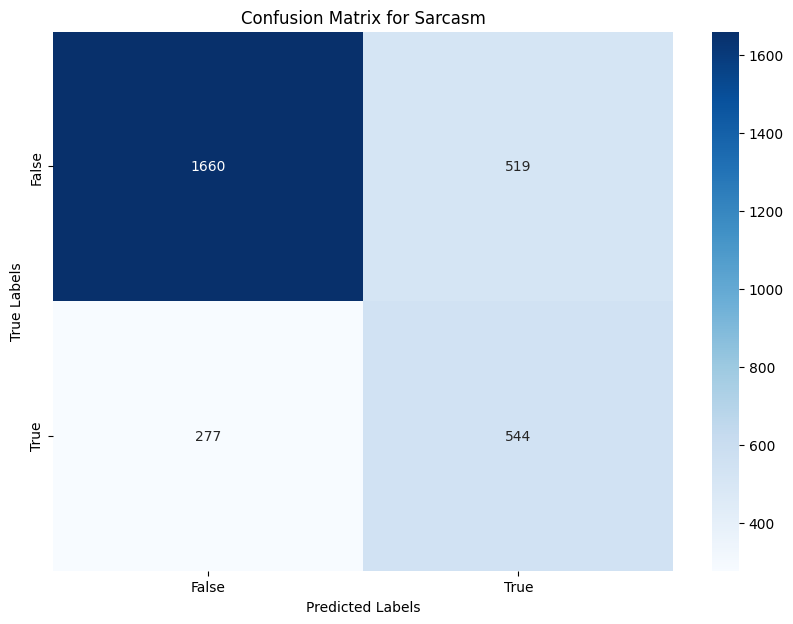


Sentiment:
  F1: 0.6144
  Precision: 0.6157
  Recall: 0.6174
  Accuracy: 0.6677
  Loss: 0.1339
  Samples: 3000

Classification Report for Sentiment:
              precision    recall  f1-score      support
NEG            0.754296  0.785331  0.769500  1677.000000
NEU            0.509740  0.419786  0.460411   748.000000
POS            0.583072  0.646957  0.613355   575.000000
accuracy       0.667667  0.667667  0.667667     0.667667
macro avg      0.615703  0.617358  0.614422  3000.000000
weighted avg   0.660502  0.667667  0.662506  3000.000000


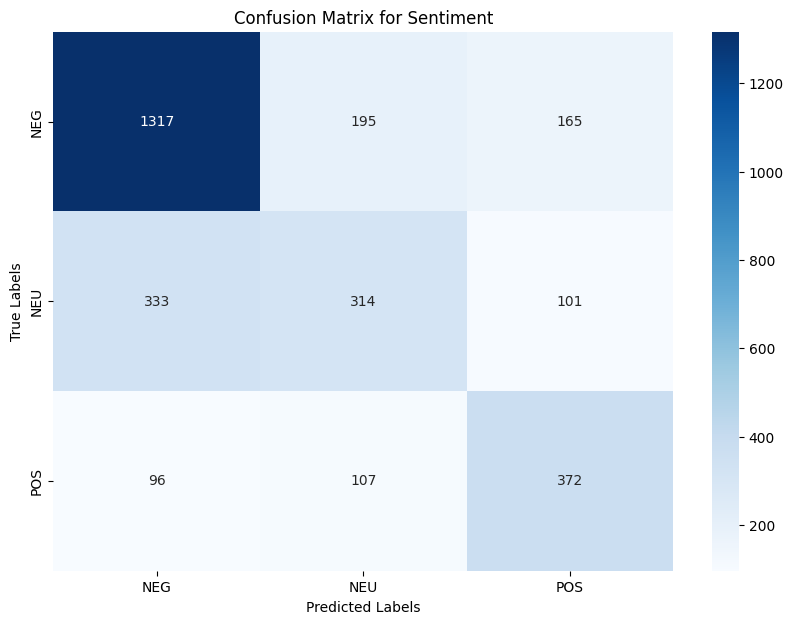


Dialect:
  F1: 0.3160
  Precision: 0.3289
  Recall: 0.4959
  Accuracy: 0.5143
  Loss: 0.0133
  Samples: 3000

Classification Report for Dialect:
              precision    recall  f1-score      support
egypt          0.305483  0.764706  0.436567   306.000000
gulf           0.338095  0.440994  0.382749   322.000000
levant         0.065256  0.787234  0.120521    47.000000
magreb         0.000000  0.000000  0.000000     2.000000
msa            0.935430  0.486440  0.640045  2323.000000
accuracy       0.514333  0.514333  0.514333     0.514333
macro avg      0.328853  0.495875  0.315977  3000.000000
weighted avg   0.792805  0.514333  0.583108  3000.000000


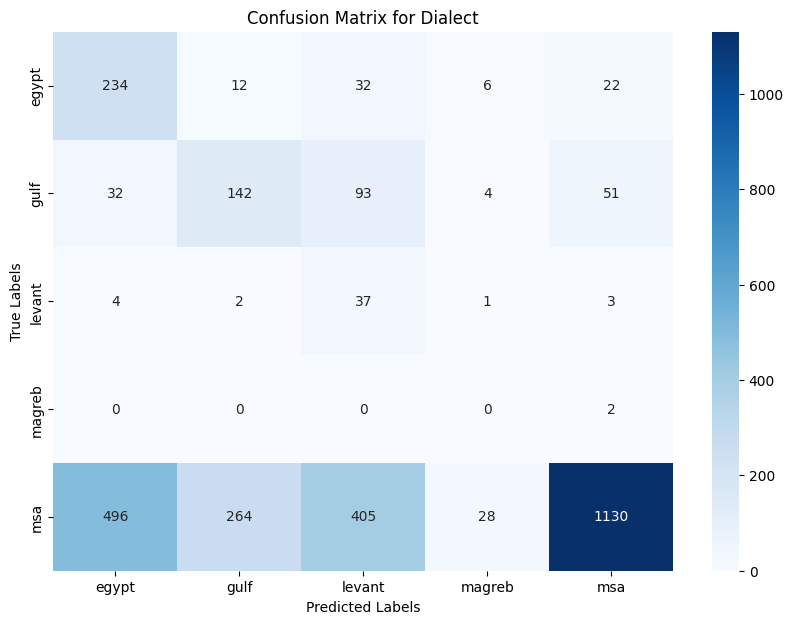

Saved 3000 predictions to Sarcasm_predictions__argmax.csv
Saved 3000 predictions to Sentiment_predictions__argmax.csv
Saved 3000 predictions to Dialect_predictions__argmax.csv


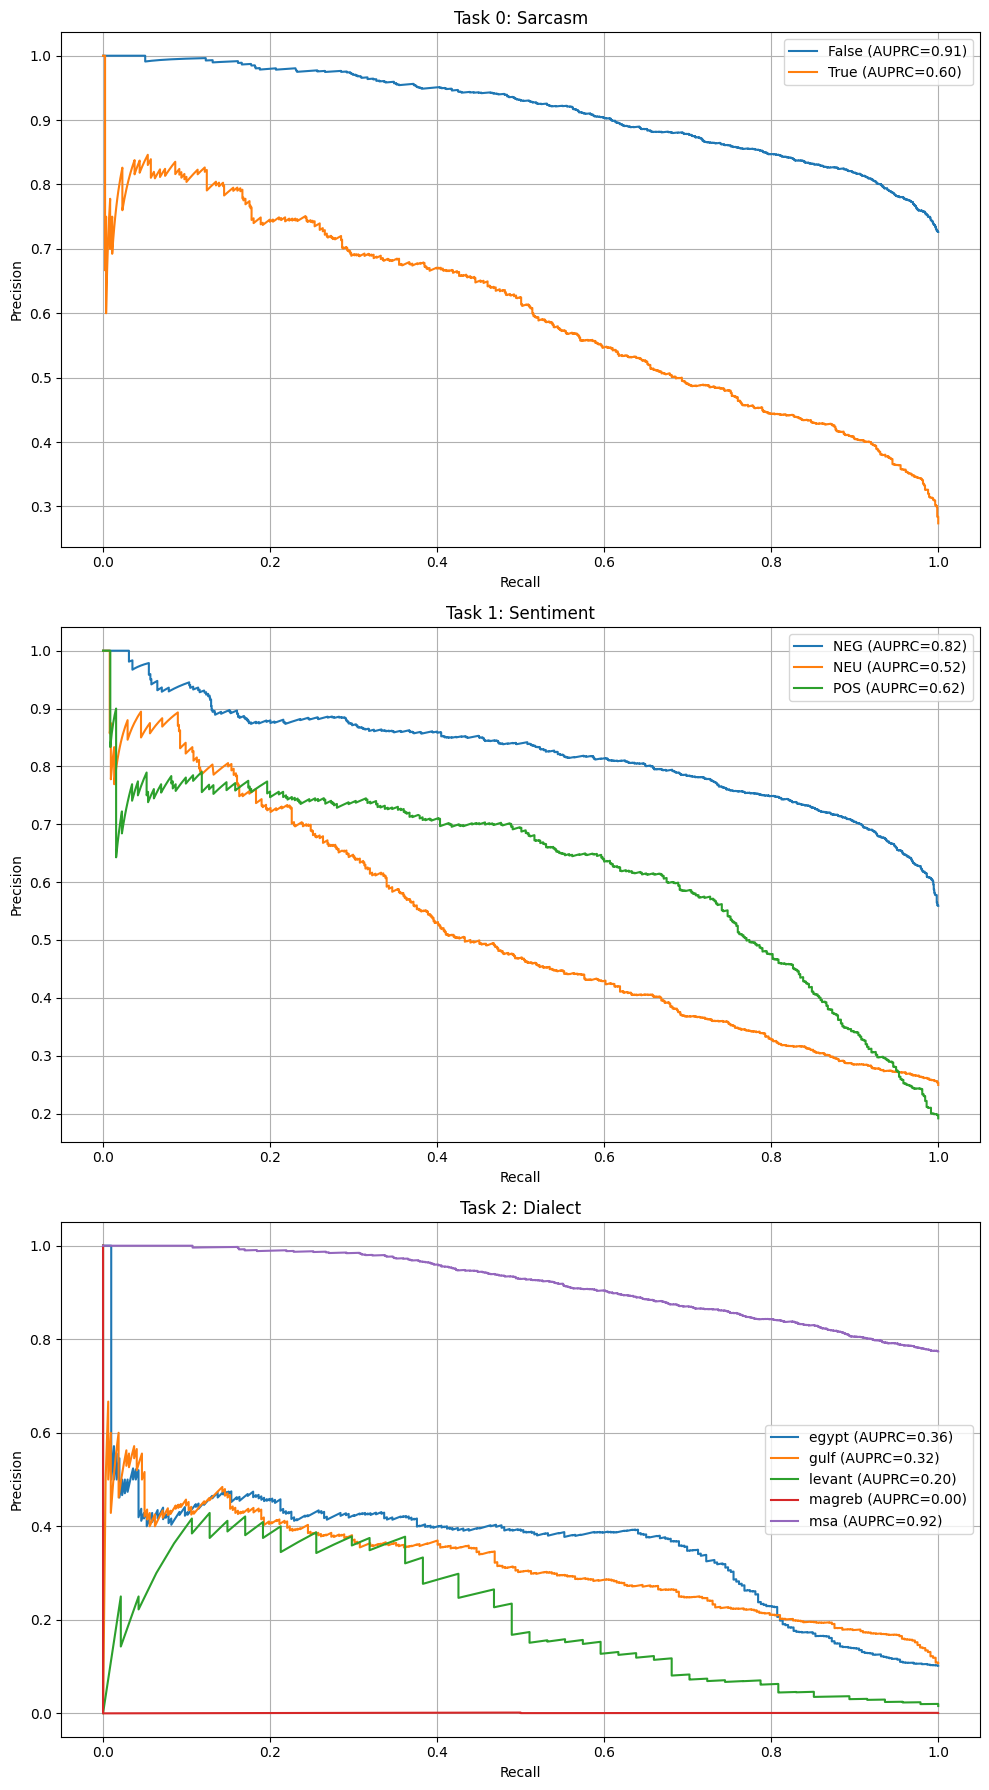

In [ ]:
print("\n=== ArgMax Baseline Predictions ===")
results_argmax = run_test_with_thresholds(
    model, tokenizer, test_df, label_encoders,
    loss_functions, train_config, '_argmax', thresholds=None
)

plot_pr_curves_per_task(results_argmax, label_encoders, task_names)

In [ ]:
shutdown_sys()